# AnimeRadar Statistical Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('combined_clean.csv')
df.head()

,title,score,members,favorites,episodes,status,genres,season,year
0,Jujutsu Kaisen,8.51,2983273,95527,24,Finished Airing,"['Action', 'Award Winning', 'Supernatural']",fall,2020
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,8.54,1756871,13487,1,Finished Airing,"['Action', 'Supernatural']",fall,2020
2,Haikyuu!! To the Top Part 2,8.56,918587,6479,12,Finished Airing,['Sports'],fall,2020
3,Tonikaku Kawaii,7.84,829699,10466,12,Finished Airing,"['Comedy', 'Romance']",fall,2020
4,Dungeon ni Deai wo Motomeru no wa Machigatteir...,7.46,674005,1966,12,Finished Airing,"['Action', 'Adventure', 'Fantasy']",fall,2020


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      500 non-null    object 
 1   score      500 non-null    float64
 2   members    500 non-null    int64  
 3   favorites  500 non-null    int64  
 4   episodes   500 non-null    int64  
 5   status     500 non-null    object 
 6   genres     500 non-null    object 
 7   season     500 non-null    object 
 8   year       500 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 35.3+ KB


In [4]:
df.describe()

,score,members,favorites,episodes,year
count,500.000000,5.000000e+02,500.000000,500.0000,500.00000
mean,7.500580,3.972140e+05,4489.992000,12.2940,2022.00000
std,0.722593,3.382377e+05,8792.496646,6.0346,1.41563
min,5.240000,6.123300e+04,58.000000,1.0000,2020.00000
25%,7.037500,1.878295e+05,829.500000,12.0000,2021.00000
50%,7.525000,2.798010e+05,1734.000000,12.0000,2022.00000
75%,8.060000,4.846555e+05,4285.500000,13.0000,2023.00000
max,9.280000,2.983273e+06,95527.000000,67.0000,2024.00000


In [5]:
#checking missing values
df.isnull().sum()

title        0
score        0
members      0
favorites    0
episodes     0
status       0
genres       0
season       0
year         0
dtype: int64

In [6]:
df['season'].value_counts()

season
fall      125
spring    125
summer    125
winter    125
Name: count, dtype: int64

In [7]:
df['status'].value_counts()

status
Finished Airing    500
Name: count, dtype: int64

In [8]:
#checking correlations
df[['score', 'members', 'favorites', 'episodes', 'year']].corr()

,score,members,favorites,episodes,year
score,1.000000,0.415442,0.452548,-0.032485,0.023960
members,0.415442,1.000000,0.820371,0.115914,-0.223851
favorites,0.452548,0.820371,1.000000,0.153609,-0.093643
episodes,-0.032485,0.115914,0.153609,1.000000,0.057239
year,0.023960,-0.223851,-0.093643,0.057239,1.000000


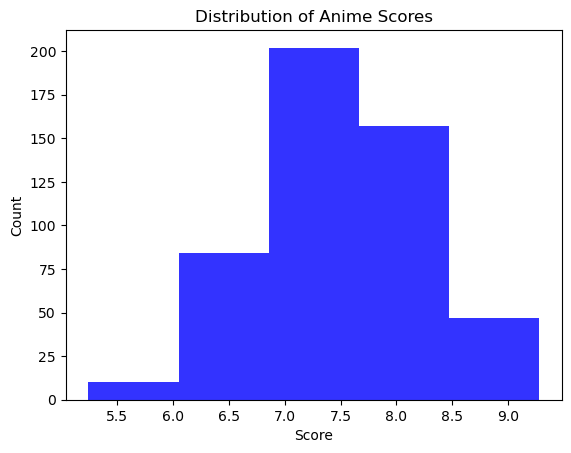

In [9]:
#plotting score histogram
data = df['score'].dropna()

plt.hist(data, bins=5, color='blue', alpha=0.8)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribution of Anime Scores')
plt.show()

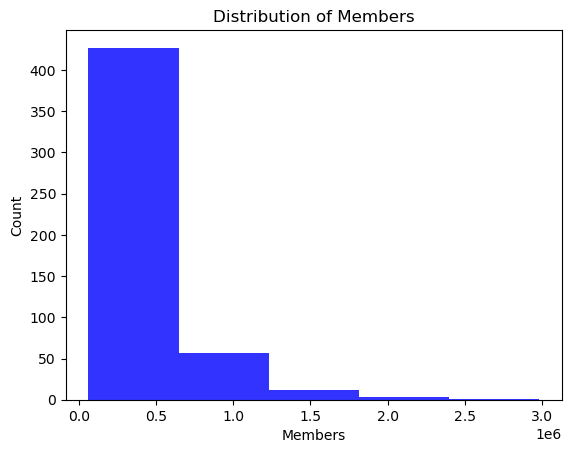

In [10]:
#plotting members histogram
data = df['members'].dropna()

plt.hist(data, bins=5, color='blue', alpha=0.8)
plt.xlabel('Members')
plt.ylabel('Count')
plt.title('Distribution of Members')
plt.show()

Members is very right skewed because a few anime have a very large member count. I used log_members to shrink the very large values so the regression is not based too heavily on the most popular anime

In [11]:
#creating log members column
df['log_members'] = np.log1p(df['members'])
df[['members','log_members']].head()

,members,log_members
0,2983273,14.908532
1,1756871,14.379046
2,918587,13.730593
3,829699,13.628819
4,674005,13.420994


In [12]:
#checking skewness
print('Members skewness:', df['members'].skew())
print('Log members skewness:', df['log_members'].skew())

Members skewness: 2.726137517485383
Log members skewness: 0.5147069723678176


The log version has less skewness than the original member count.

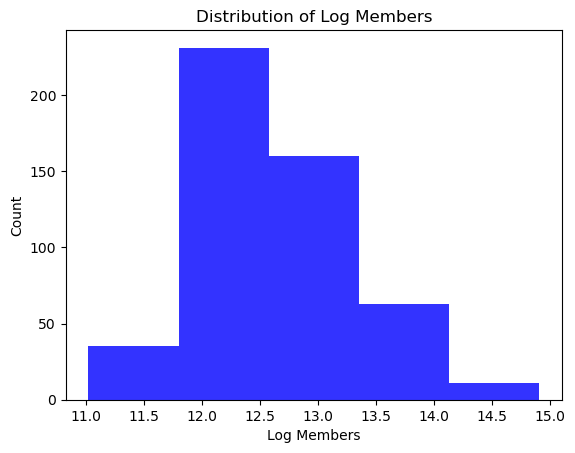

In [13]:
data = df['log_members'].dropna()

plt.hist(data, bins=5, color='blue', alpha=0.8)
plt.xlabel('Log Members')
plt.ylabel('Count')
plt.title('Distribution of Log Members')
plt.show()

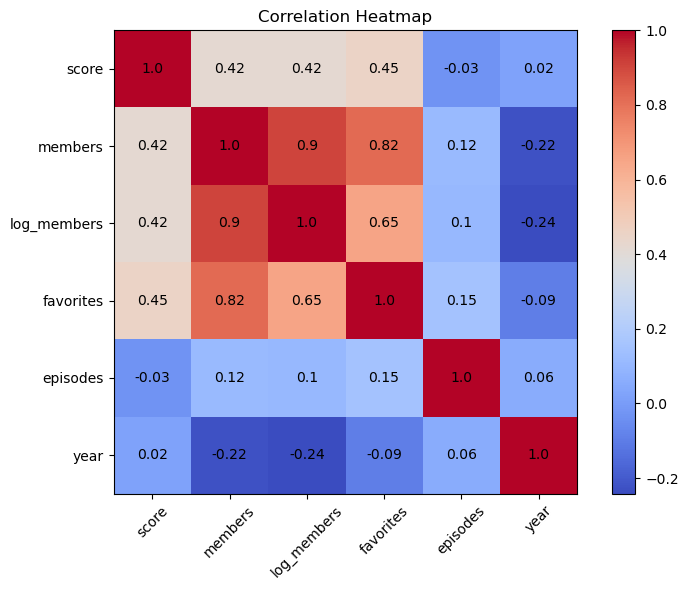

In [14]:
#creating heatmap
numeric_df = df[['score', 'members', 'log_members', 'favorites', 'episodes', 'year']].dropna()
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2), ha='center', va='center')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

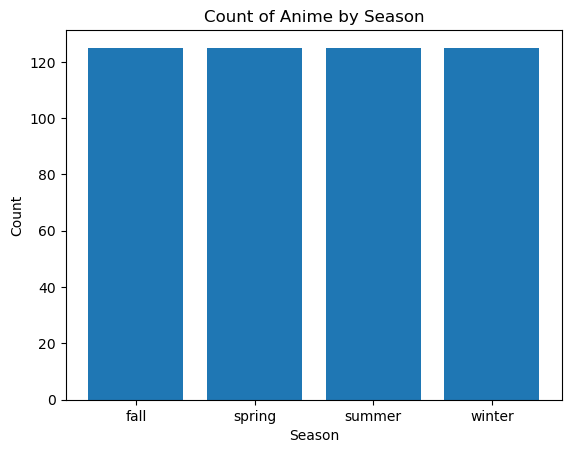

In [15]:
#plotting season counts
season_counts = df['season'].value_counts()

plt.bar(season_counts.index, season_counts.values)
plt.xlabel('Season')
plt.ylabel('Count')
plt.title('Count of Anime by Season')
plt.show()

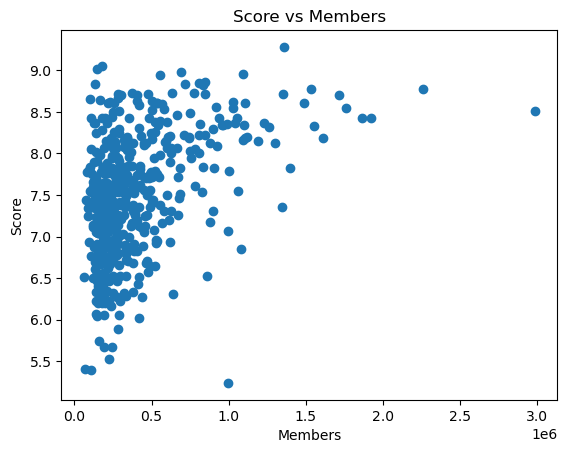

In [16]:
plt.scatter(df['members'], df['score'])
plt.xlabel('Members')
plt.ylabel('Score')
plt.title('Score vs Members')
plt.show()

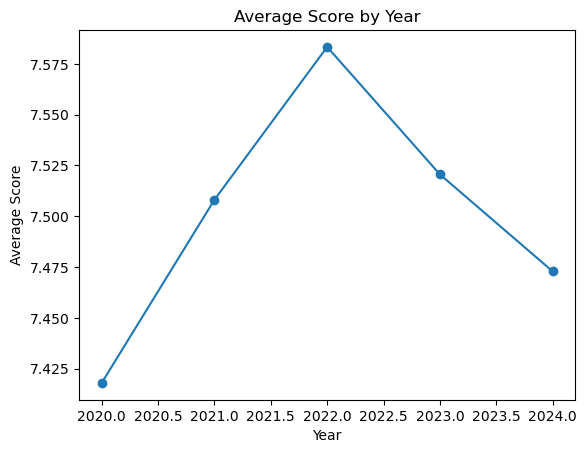

In [17]:
year_score = df.groupby('year')['score'].mean()

plt.plot(year_score.index, year_score.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.title('Average Score by Year')
plt.show()

In [18]:
season_score = df.groupby('season')['score'].mean().sort_values(ascending=False)
season_score

season
fall      7.63448
winter    7.49520
spring    7.46720
summer    7.40544
Name: score, dtype: float64

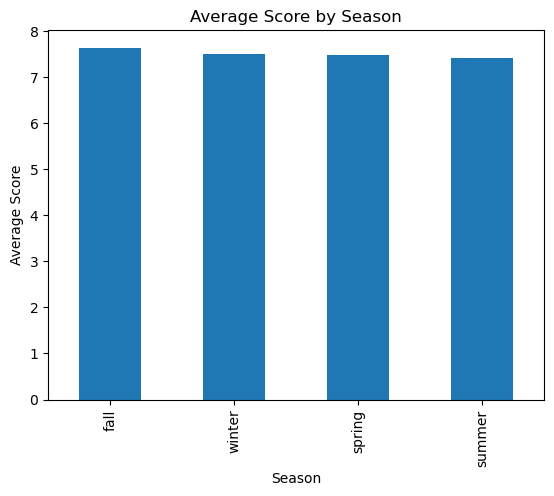

In [19]:
season_score.plot(kind='bar')
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.title('Average Score by Season')
plt.show()

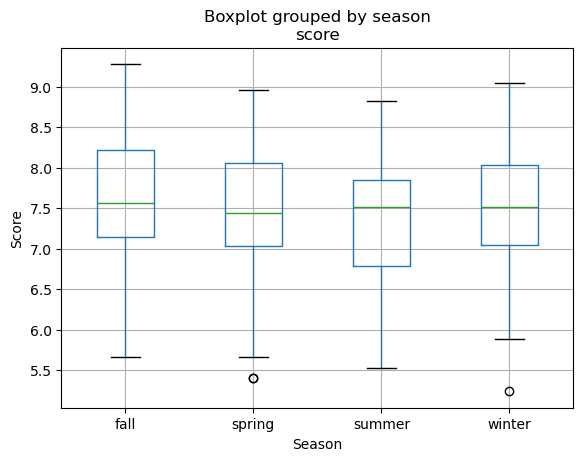

In [20]:
df.boxplot(column='score', by='season')
plt.xlabel('Season')
plt.ylabel('Score')
plt.show()

In [21]:
#creating log favorites column
df['log_favorites'] = np.log1p(df['favorites'])
df[['favorites', 'log_favorites']].head()

,favorites,log_favorites
0,95527,11.467175
1,13487,9.509556
2,6479,8.776476
3,10466,9.255983
4,1966,7.584265


In [22]:
#checking skewness
print('Favorites skewness:', df['favorites'].skew())
print('Log favorites skewness:', df['log_favorites'].skew())

Favorites skewness: 5.6062567471000415
Log favorites skewness: 0.4902083761863126


Favorites is also right skewed because some anime have way more favorites than others. I used log favorites for the same reason I used log members.

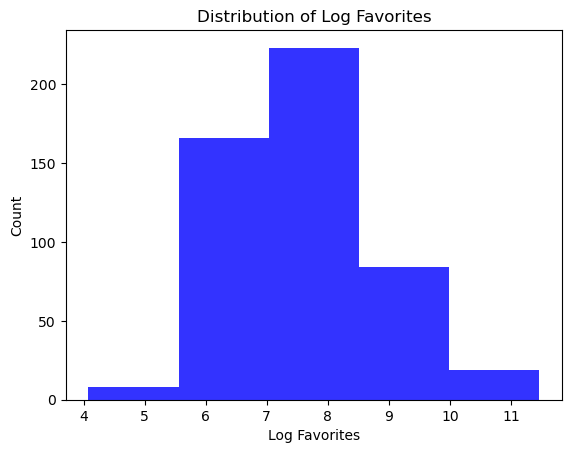

In [23]:
#plotting log favorites histogram
data = df['log_favorites'].dropna()

plt.hist(data, bins=5, color='blue', alpha=0.8)
plt.xlabel('Log Favorites')
plt.ylabel('Count')
plt.title('Distribution of Log Favorites')
plt.show()

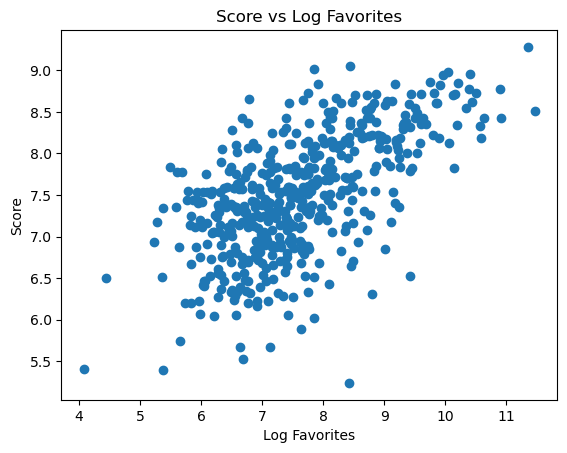

In [24]:
plt.scatter(df['log_favorites'], df['score'])
plt.xlabel('Log Favorites')
plt.ylabel('Score')
plt.title('Score vs Log Favorites')
plt.show()

# 95% Confidence Interval for Mean Score

In [25]:
#calculating confidence interval
mean_score = df['score'].mean()
std_score = df['score'].std()
n = df['score'].count()

margin_error = stats.t.ppf(0.975, n - 1) * std_score / np.sqrt(n)
lower_bound = mean_score - margin_error
upper_bound = mean_score + margin_error

print('Mean score:', mean_score)
print('95% confidence interval:', lower_bound, upper_bound)

Mean score: 7.50058
95% confidence interval: 7.43708908069605 7.56407091930395


# Normality Test for Score

In [26]:
#testing normality
statistic, p_value = stats.shapiro(df['score'].dropna())

print('Shapiro statistic:', statistic)
print('p-value:', p_value)

if p_value < 0.05:
    print('Does not look normally distributed')
else:
    print('Normally distributed')

Shapiro statistic: 0.992908636229908
p-value: 0.01831342812271558
Does not look normally distributed


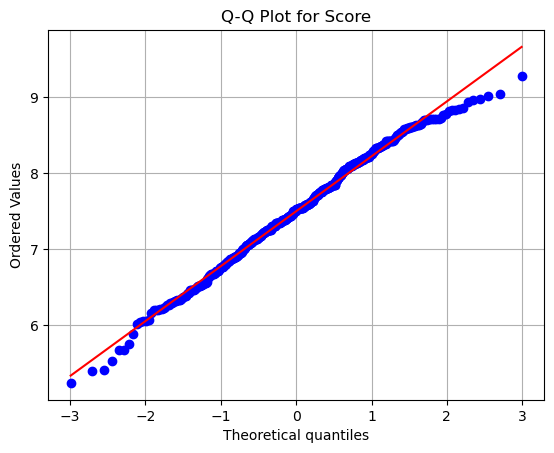

In [27]:
stats.probplot(df['score'].dropna(), dist='norm', plot=plt)
plt.title('Q-Q Plot for Score')
plt.grid(True)
plt.show()

# Fall vs Spring T-Test

In [28]:
#running t-test
fall_scores = df[df['season'] == 'fall']['score'].dropna()
spring_scores = df[df['season'] == 'spring']['score'].dropna()

t_stat, p_value = stats.ttest_ind(fall_scores, spring_scores, equal_var=False)

print('Fall mean:', fall_scores.mean())
print('Spring mean:', spring_scores.mean())
print('t-statistic:', t_stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('Significant difference between Fall and Spring scores')
else:
    print('Not a significant difference between Fall and Spring scores')

Fall mean: 7.634480000000002
Spring mean: 7.467200000000002
t-statistic: 1.8416316190417648
p-value: 0.0667231680075794
Not a significant difference between Fall and Spring scores


# ANOVA by Season

In [29]:
#running anova
winter_scores = df[df['season'] == 'winter']['score'].dropna()
spring_scores = df[df['season'] == 'spring']['score'].dropna()
summer_scores = df[df['season'] == 'summer']['score'].dropna()
fall_scores = df[df['season'] == 'fall']['score'].dropna()

f_stat, p_value = stats.f_oneway(winter_scores, spring_scores, summer_scores, fall_scores)

print('F-statistic:', f_stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('At least one season has a different average score')
else:
    print('The average scores are not significantly different by season')

F-statistic: 2.261303724291016
p-value: 0.08049533569856462
The average scores are not significantly different by season


# Pearson Correlation Between Score and Log Members

In [30]:
#calculating correlation
corr, p_value = stats.pearsonr(df['score'].dropna(), df['log_members'].dropna())

print('Correlation:', corr)
print('p-value:', p_value)

if p_value < 0.05:
    print('Significant relationship between score and log members')
else:
    print('Not a significant relationship between score and log members')

Correlation: 0.4164372207172967
p-value: 2.155040522926038e-22
Significant relationship between score and log members


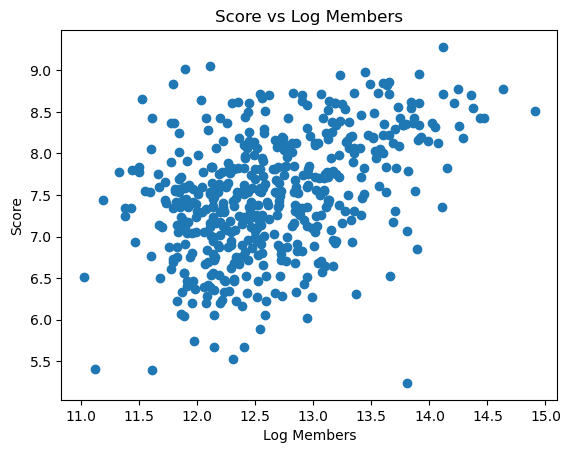

In [31]:
plt.scatter(df['log_members'], df['score'])
plt.xlabel('Log Members')
plt.ylabel('Score')
plt.title('Score vs Log Members')
plt.show()

# Pearson Correlation Between Score and Log Favorites

In [32]:
#calculating correlation
corr, p_value = stats.pearsonr(df['score'].dropna(), df['log_favorites'].dropna())

print('Correlation:', corr)
print('p-value:', p_value)

if p_value < 0.05:
    print('Significant relationship between score and log favorites')
else:
    print('Not a significant relationship between score and log favorites')

Correlation: 0.6149936985940138
p-value: 2.3924839852155288e-53
Significant relationship between score and log favorites


# Simple Linear Regression

In [33]:
#running regression
reg_df = df[['score', 'log_members']].dropna()
x = reg_df['log_members']
y = reg_df['score']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print('Intercept:', intercept)
print('Slope:', slope)
print('R-squared:', r_value ** 2)
print('p-value:', p_value)
print('Standard error:', std_err)

if p_value < 0.05:
    print('Log members is a significant predictor of score')
else:
    print('Log members is not a significant predictor of score')

Intercept: 1.8400913647233095
Slope: 0.4477004131012222
R-squared: 0.17341995879874642
p-value: 2.1550405229261145e-22
Standard error: 0.04379915598002314
Log members is a significant predictor of score


This regression checks whether popularity helps explain score after using log members

# Residual Analysis

In [34]:
#creating residuals
df['predicted_score'] = intercept + slope * df['log_members']
df['residual'] = df['score'] - df['predicted_score']

df[['score', 'predicted_score', 'residual']].head()

,score,predicted_score,residual
0,8.51,8.514647,-0.004647
1,8.54,8.277596,0.262404
2,8.56,7.987284,0.572716
3,7.84,7.941719,-0.101719
4,7.46,7.848676,-0.388676


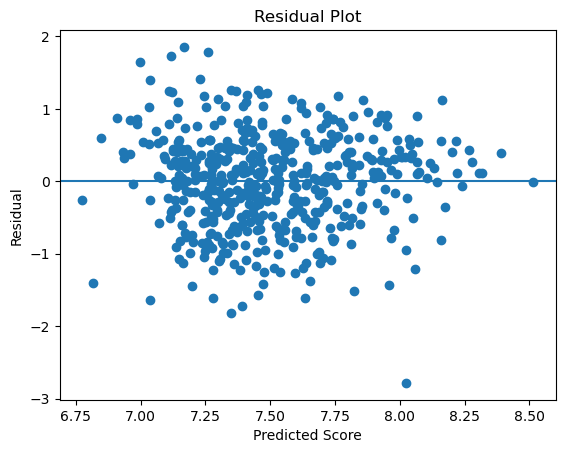

In [35]:
#plotting residuals
plt.scatter(df['predicted_score'], df['residual'])
plt.axhline(y=0)
plt.xlabel('Predicted Score')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

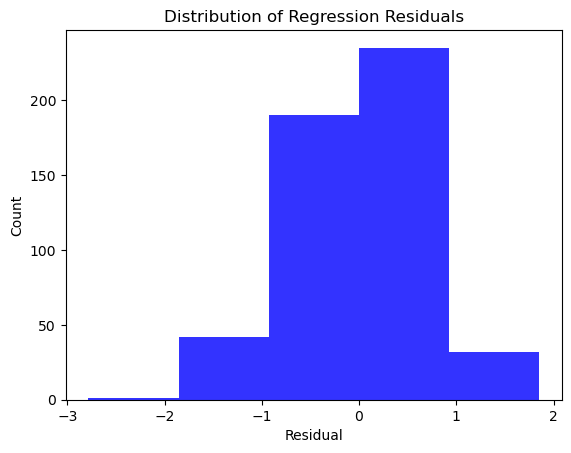

In [36]:
#plotting residual histogram
data = df['residual'].dropna()

plt.hist(data, bins=5, color='blue', alpha=0.8)
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Distribution of Regression Residuals')
plt.show()

The residual plot shows how far the predicted scores are from the real scores

# High-Score Classification

In [37]:
#creating high score groups
df['high_score'] = np.where(df['score'] >= 8, 'High Score', 'Not High Score')
df['high_score'].value_counts()

high_score
Not High Score    363
High Score        137
Name: count, dtype: int64

In [38]:
high_score_summary = df.groupby('high_score')[['score', 'members', 'favorites', 'episodes']].mean()
high_score_summary

,score,members,favorites,episodes
high_score,,,,
High Score,8.382555,651746.459854,11188.072993,12.620438
Not High Score,7.167713,301150.840220,1962.066116,12.170799


In [39]:
pd.crosstab(df['season'], df['high_score'])

high_score,High Score,Not High Score
season,,
fall,42,83
spring,34,91
summer,27,98
winter,34,91


# Chi-Square Test for Season and High Score

In [40]:
#running chi-square test
table = pd.crosstab(df['season'], df['high_score'])
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print('Chi-square statistic:', chi2)
print('p-value:', p_value)
print('Degrees of freedom:', dof)

if p_value < 0.05:
    print('Season and high score group are related')
else:
    print('Season and high score group are not significantly related')

Chi-square statistic: 4.534395045343951
p-value: 0.20924276967945157
Degrees of freedom: 3
Season and high score group are not significantly related


## Top Anime Tables

In [41]:
#sorting top anime
df.sort_values('score', ascending=False)[['title', 'score', 'members', 'favorites', 'season', 'year']].head(10)

,title,score,members,favorites,season,year
75,Sousou no Frieren,9.28,1354878,86012,fall,2023
424,Gintama: The Final,9.05,180884,4637,winter,2021
114,One Piece Fan Letter,9.02,146654,2543,fall,2024
57,Bleach: Sennen Kessen-hen,8.98,690298,23064,fall,2022
176,Kaguya-sama wa Kokurasetai: Ultra Romantic,8.96,1094783,33046,spring,2022
157,Fruits Basket: The Final,8.94,556503,21277,spring,2021
450,Shingeki no Kyojin: The Final Season - Kankets...,8.86,846372,17235,winter,2023
76,Kusuriya no Hitorigoto,8.85,805604,27072,fall,2023
142,Kingdom 3rd Season,8.84,131593,2746,spring,2020
257,Violet Evergarden Movie,8.83,718381,9725,summer,2020


In [42]:
#sorting top anime
df.sort_values('members', ascending=False)[['title', 'score', 'members', 'favorites', 'season', 'year']].head(10)

,title,score,members,favorites,season,year
0,Jujutsu Kaisen,8.51,2983273,95527,fall,2020
400,Shingeki no Kyojin: The Final Season,8.78,2260937,53905,winter,2021
50,Chainsaw Man,8.43,1922428,55090,fall,2022
175,Spy x Family,8.42,1862244,41194,spring,2022
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,8.54,1756871,13487,fall,2020
425,Kimetsu no Yaiba: Yuukaku-hen,8.70,1715034,25153,winter,2022
401,Horimiya,8.18,1612067,39553,winter,2021
402,Mushoku Tensei: Isekai Ittara Honki Dasu,8.33,1550453,39056,winter,2021
426,Shingeki no Kyojin: The Final Season Part 2,8.77,1535035,32219,winter,2022
125,Kaguya-sama wa Kokurasetai? Tensai-tachi no Re...,8.61,1485556,19039,spring,2020


In [43]:
#sorting top anime
df.sort_values('favorites', ascending=False)[['title', 'score', 'members', 'favorites', 'season', 'year']].head(10)

,title,score,members,favorites,season,year
0,Jujutsu Kaisen,8.51,2983273,95527,fall,2020
75,Sousou no Frieren,9.28,1354878,86012,fall,2023
50,Chainsaw Man,8.43,1922428,55090,fall,2022
400,Shingeki no Kyojin: The Final Season,8.78,2260937,53905,winter,2021
175,Spy x Family,8.42,1862244,41194,spring,2022
401,Horimiya,8.18,1612067,39553,winter,2021
402,Mushoku Tensei: Isekai Ittara Honki Dasu,8.33,1550453,39056,winter,2021
56,Bocchi the Rock!,8.73,773247,36129,fall,2022
300,Cyberpunk: Edgerunners,8.62,1025161,34246,summer,2022
176,Kaguya-sama wa Kokurasetai: Ultra Romantic,8.96,1094783,33046,spring,2022
